In [1]:
import pickle

import numpy as np
import matplotlib.pyplot as plt

import Pk_library as PKL



In [2]:
import numpy as np

def power_spectrum_3d(f, L, m):
    """
    Pylians-style isotropic monopole P(k) for a 3D density contrast field.

    Parameters
    ----------
    f : ndarray, shape (m,m,m)
        Density contrast field delta(x).
    L : float
        Box size.
    m : int
        Grid size.

    Returns
    -------
    k : ndarray
        Mean |k| in each shell (Pylians-style).
    Pk : ndarray
        Mean power in each shell.
    Nmodes : ndarray
        Number of modes in each shell.
    """
    f = np.asarray(f, dtype=np.float64)
    if f.shape != (m, m, m):
        raise ValueError("f must have shape (m,m,m)")

    kF = 2.0 * np.pi / L
    dx = L / m

    fk = np.fft.fftn(f)
    power = (L**3 / m**6) * np.abs(fk)**2

    k1d = np.fft.fftfreq(m, d=dx) * L   # integer mode numbers n_x, n_y, n_z
    nx, ny, nz = np.meshgrid(k1d, k1d, k1d, indexing="ij")
    nmag = np.sqrt(nx**2 + ny**2 + nz**2)

    nmag = nmag.ravel()
    power = power.ravel()

    shell = np.floor(nmag).astype(int)

    shell_max = shell.max()
    Nmodes = np.bincount(shell, minlength=shell_max + 1)
    ksum   = np.bincount(shell, weights=nmag * kF, minlength=shell_max + 1)
    psum   = np.bincount(shell, weights=power, minlength=shell_max + 1)

    mask = Nmodes > 0
    k = ksum[mask] / Nmodes[mask]
    Pk = psum[mask] / Nmodes[mask]
    Nmodes = Nmodes[mask]

    # drop DC bin
    return k[1:], Pk[1:], Nmodes[1:]

In [3]:
fold_list = ["remote_data/imex_ARK4(3)6L[2]SA_256_5e-05/","remote_data/imex_ARK4(3)6L[2]SA_256_1e-05/",\
             "remote_data/imex_ARK4(3)6L[2]SA_256_1e-06/"]
dt_list = [float(folder.split("_")[-1][:-1]) for folder in fold_list]
print(dt_list)

folder_PR = "_dataij_hunit_TSC_cosmo_I_projRlx_E1_v1.5_ini4/imex_ARK4(3)6L[2]SA_256_5e-05/"
folder_B = f"_dataij_hunit_TSC_cosmo_I_E1_v1.5_ini4/imex_ARK4(3)6L[2]SA_256_5e-05/"


isub = 10

with open(folder_B+ "case_dict.pkl", 'rb') as file:
        data_B = pickle.load(file)
        m_B = data_B["frame_list"][0].shape
        XX = data_B["X"]
X = XX[0]
Y = XX[1]
Z = XX[2]
Lbox = 1.0
N = m_B[0]
print( m_B, X.shape, Y.shape, Z.shape)


file_B = [folder_B+"frame_"for folder_B in fold_list]
file_PR = folder_PR+"frame_"


final_t = "1.0"
initial_t = "initial"
frame_initial = np.load(folder_B+"frame_" + initial_t+ ".npz")['frame']
#frame_ref = np.load(folder_ref + "frame_" + final_t + ".npz")['frame']
frame_B = [np.load(file_B_i + final_t+ ".npz")['frame'] for file_B_i in file_B]
frame_PR = np.load(file_PR + final_t+ ".npz")['frame']

#rho_ref = np.square(np.abs(frame_ref))
# rho_ref_64 = 1.0*rho_ref
rho_initial = np.square(np.abs(frame_initial))
rho_initial_64 = 1.0*rho_initial
rho_B = [np.square(np.abs(frame_B_i)) for frame_B_i in frame_B]
rho_B_64 = [1.0*rho_B_i for rho_B_i in rho_B]
rho_PR = np.square(np.abs(frame_PR))
rho_PR_64 = 1.0*rho_PR

#rho_ref = np.array(rho_ref, dtype=np.float32)
rho_B = [np.array(rho_B_i, dtype=np.float32) for rho_B_i in rho_B]
rho_PR = np.array(rho_PR, dtype=np.float32)
rho_initial = np.array(rho_initial, dtype=np.float32)

[5e-05, 1e-05, 1e-06]
(256, 256, 256) (256, 256, 256) (256, 256, 256) (256, 256, 256)



Computing power spectrum of the field...
Time to complete loop = 0.44
Time taken = 0.58 seconds
8.899641224696953 1390.2843163141772 221 0.0390625


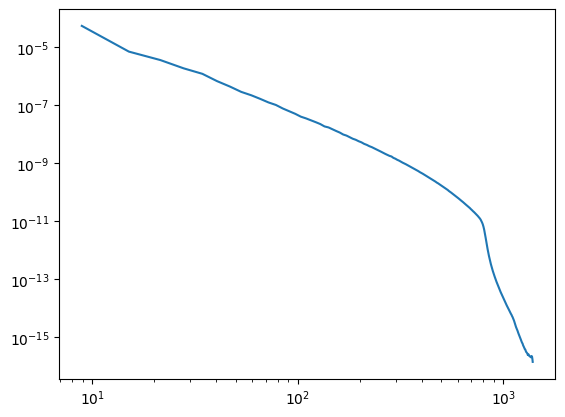

In [4]:


        # compute power spectrum
Pk_initial = PKL.Pk(rho_initial-1.0, BoxSize=1.0,MAS=None)

    # Pk is a python class containing the 1D, 2D and 3D power spectra, that can be retrieved as

    # 1D P(k)
k1D_initial      = Pk_initial.k1D
Pk1D_initial     = Pk_initial.Pk1D
Nmodes1D_initial = Pk_initial.Nmodes1D

    # 2D P(k)
kpar_initial     = Pk_initial.kpar
kper_initial     = Pk_initial.kper
Pk2D_initial     = Pk_initial.Pk2D
Nmodes2D_initial = Pk_initial.Nmodes2D

    # 3D P(k)
k_initial       = Pk_initial.k3D
Pk0_initial     = Pk_initial.Pk[:,0] #monopole
Pk2_initial     = Pk_initial.Pk[:,1] #quadrupole
Pk4_initial     = Pk_initial.Pk[:,2] #hexadecapole
Pkphase_initial = Pk_initial.Pkphase #power spectrum of the phases
Nmodes_initial  = Pk_initial.Nmodes3D

plt.loglog(k_initial, Pk0_initial, label='Initial')
print(np.min(k_initial),np.max(k_initial), len(k_initial),10.0/256)

In [5]:


Pk = [PKL.Pk(rho_B_i-1.0, BoxSize=Lbox,MAS=None) for rho_B_i in rho_B]

  

k1D      = [Pk_i.k1D for Pk_i in Pk]
Pk1D     = [Pk_i.Pk1D for Pk_i in Pk]
Nmodes1D = [Pk_i.Nmodes1D for Pk_i in Pk]

    # 2D P(k)
kpar     = [Pk_i.kpar for Pk_i in Pk]
kper     = [Pk_i.kper for Pk_i in Pk]
Pk2D     = [Pk_i.Pk2D for Pk_i in Pk]
Nmodes2D = [Pk_i.Nmodes2D for Pk_i in Pk]

    # 3D P(k)
k       = [Pk_i.k3D for Pk_i in Pk]
Pk0     = [Pk_i.Pk[:,0] for Pk_i in Pk] 
Pk2     = [Pk_i.Pk[:,1] for Pk_i in Pk] 
Pk4     = [Pk_i.Pk[:,2] for Pk_i in Pk] 
Pkphase = [Pk_i.Pkphase for Pk_i in Pk] 
Nmodes  = [Pk_i.Nmodes3D for Pk_i in Pk]

###############################################

Pk_PR = PKL.Pk(rho_PR-1.0, BoxSize=Lbox,MAS=None)


k1D_PR      = Pk_PR.k1D
Pk1D_PR     = Pk_PR.Pk1D
Nmodes1D_PR = Pk_PR.Nmodes1D

    # 2D P(k)
kpar_PR     = Pk_PR.kpar
kper_PR     = Pk_PR.kper
Pk2D_PR     = Pk_PR.Pk2D
Nmodes2D_PR = Pk_PR.Nmodes2D

    # 3D P(k)
k_PR       = Pk_PR.k3D
Pk0_PR     = Pk_PR.Pk[:,0] 
Pk2_PR     = Pk_PR.Pk[:,1]
Pk4_PR     = Pk_PR.Pk[:,2] 
Pkphase_PR = Pk_PR.Pkphase 
Nmodes_PR  = Pk_PR.Nmodes3D
print( Pk2D_PR.shape)
###############################################


Computing power spectrum of the field...
Time to complete loop = 0.29
Time taken = 0.43 seconds

Computing power spectrum of the field...
Time to complete loop = 0.30
Time taken = 0.42 seconds

Computing power spectrum of the field...
Time to complete loop = 0.29
Time taken = 0.42 seconds

Computing power spectrum of the field...
Time to complete loop = 0.29
Time taken = 0.42 seconds
(23478,)


[4.0, 3.0, 2.0, 1.0]
5e-05 5e-05/ 4.0
mean difference of 5e-05 with respect to dt = 1e-06: 0.0002910852530032461 0.00169125488144296
1e-05 1e-05/ 3.0
mean difference of 1e-05 with respect to dt = 1e-06: 0.00020318662942041716 0.0014211575372169716
1e-06 1e-06/ 2.0
mean difference of 1e-06 with respect to dt = 1e-06: 0.0 0.0
mean difference of PR with respect to dt = 1e-06: 1.2665127421729613e-06 9.973098648308198e-06


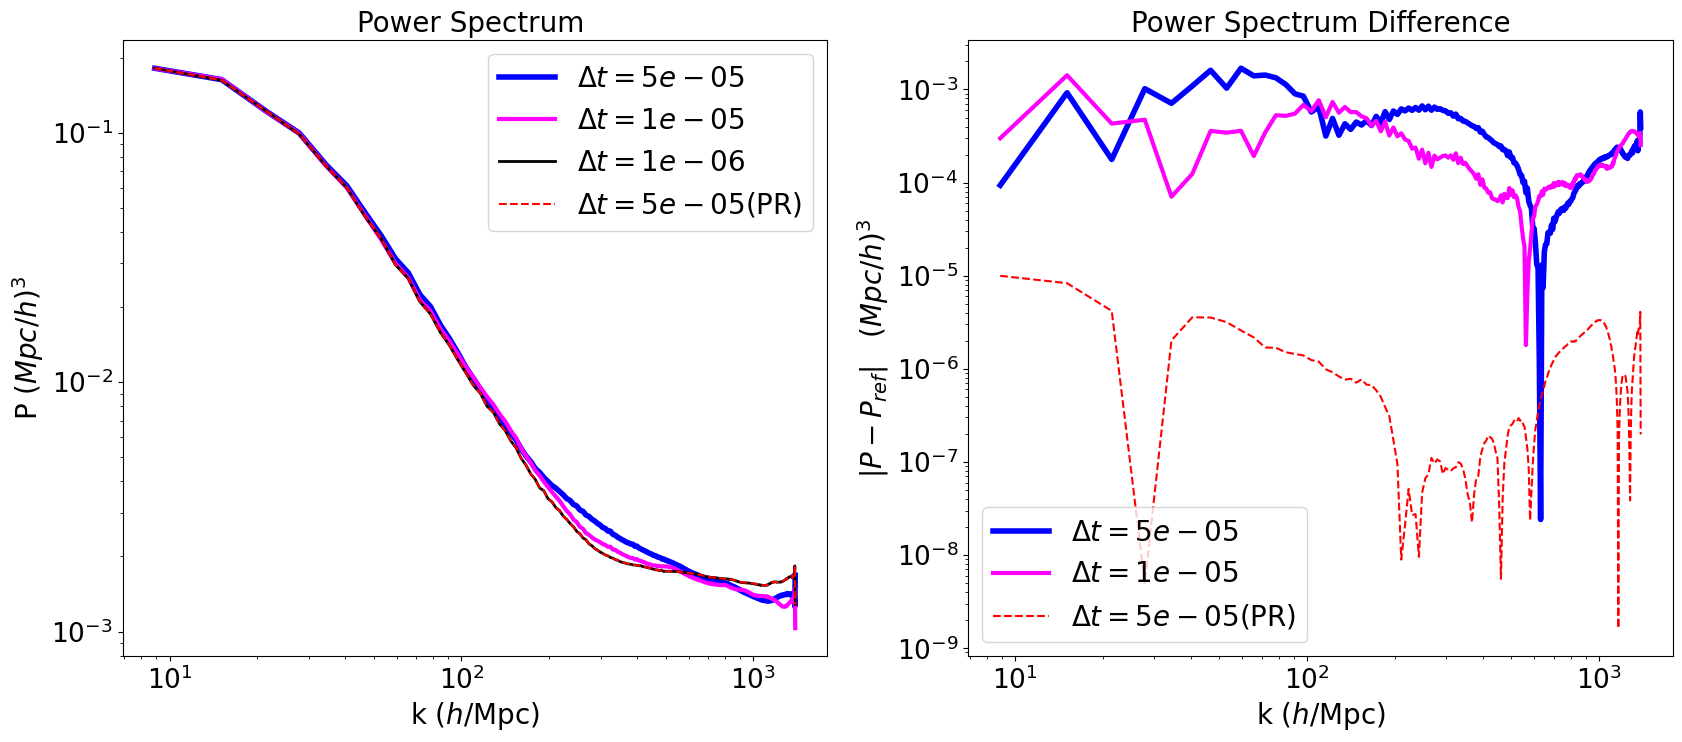

In [6]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(20, 8))
gs = gridspec.GridSpec(1, 2, figure=fig)
colors = ['blue', 'magenta',  'black','orange']
lw = [4.0,3.0,2.0,1.0]
print(lw)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax1.tick_params(axis='both', which='major', labelsize=19)
ax2.tick_params(axis='both', which='major', labelsize=19)
#ax2.set_xlim(200, 1390.2843163141772)
#ax2.set_ylim(1e-3,4e-3)
    #ax2.plot(k_initial, Pk0_initial, label='Initial')
# ax2.plot(k_ref, Pk0_ref, label='Reference')
j=0
for pk0_i, k_i, dt, lw_i in zip(Pk0, k, dt_list, lw):
    print(dt,fold_list[j].split("_")[-1], lw_i)
    diff = np.abs((pk0_i - Pk0[-1]))
    print(f"mean difference of {dt} with respect to dt = {dt_list[-1]}:", np.mean(diff),np.max(diff))
    ax1.plot(k_i, pk0_i, label=f'$\Delta t = {dt}$', linewidth=lw_i,color=colors[j])
    if j!= len(Pk0)-1:
        ax2.plot(k_i, diff, label=f'$\Delta t= {dt}$', linewidth=lw_i,color=colors[j])
    j=j+1
diff_PR = np.abs((Pk0_PR- Pk0[-1]))
print(f"mean difference of PR with respect to dt = {dt_list[-1]}:", np.mean(diff_PR), np.max(diff_PR))
ax2.plot(k_PR, diff_PR,"r--" ,label=f'$\Delta t = 5e-05$(PR)')
ax1.plot(k_PR, Pk0_PR,"r--" ,label=f'$\Delta t = 5e-05$(PR)')
#ax2.plot(k_initial, Pk0_initial*128.0*128.0, label='Initial')
   

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('k $(h$/Mpc$)$',fontsize=20)
ax2.set_ylabel('$|P-P_{ref}|\quad (Mpc/h)^3$',fontsize=20)
ax2.set_title('Power Spectrum Difference',fontsize=20)
ax2.legend(loc='best',fontsize=20)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('k $(h$/Mpc$)$',fontsize=20)
ax1.set_ylabel('P $(Mpc/h)^3$',fontsize=20)
ax1.set_title('Power Spectrum ',fontsize=20)
ax1.legend(loc='best',fontsize=20)

plt.savefig("figures_cosmo_3d/power_spectrum_difference.pdf")

[4.0, 3.0, 2.0, 1.0]
5e-05 5e-05/ 4.0
mean relative difference of 5e-05 with respect to dt = 1e-06: 0.0002910852530032461
max relative difference of 5e-05 with respect to dt = 1e-06: 0.00169125488144296
1e-05 1e-05/ 3.0
mean relative difference of 1e-05 with respect to dt = 1e-06: 0.00020318662942041716
max relative difference of 1e-05 with respect to dt = 1e-06: 0.0014211575372169716
1e-06 1e-06/ 2.0
mean relative difference of 1e-06 with respect to dt = 1e-06: 0.0
max relative difference of 1e-06 with respect to dt = 1e-06: 0.0
mean relative difference of PR with respect to dt = 1e-06: 1.2665127421729613e-06
max relative difference of PR with respect to dt = 1e-06: 9.973098648308198e-06


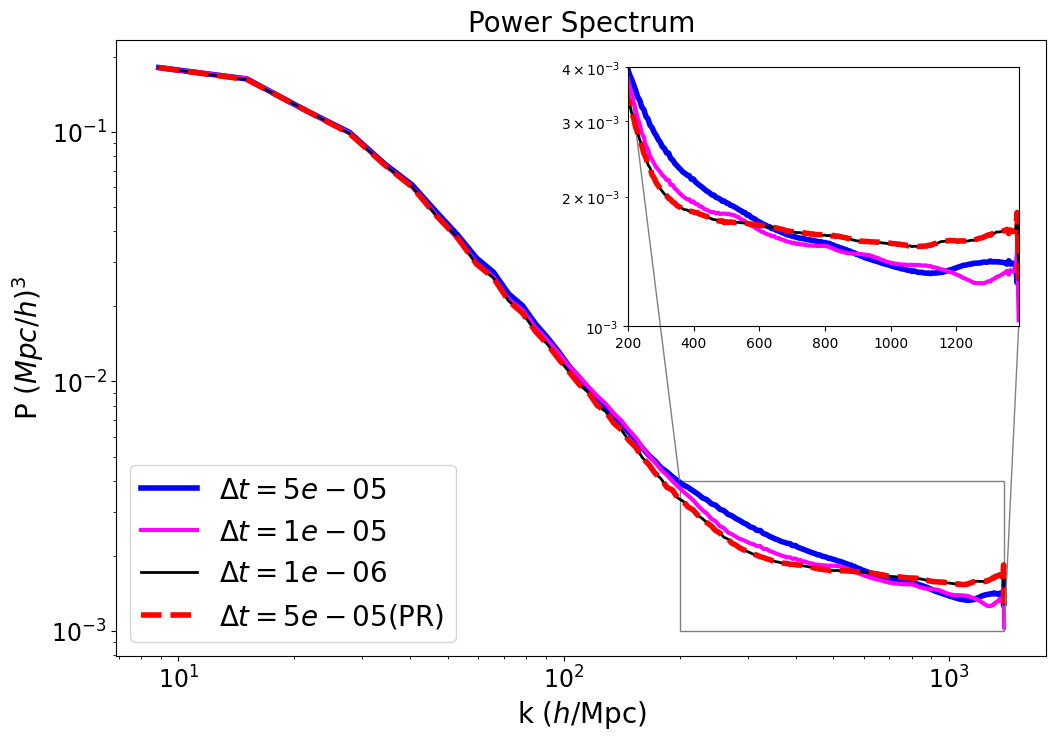

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

fig, ax = plt.subplots(figsize=(12, 8))

lw = [4.0, 3.0, 2.0, 1.0]
colors = ['blue', 'magenta',  'black','orange']
print(lw)

j = 0
diff_list_mean = []
diff_list_max = []
for pk0_i, k_i, dt, lw_i in zip(Pk0, k, dt_list, lw):
    print(dt, fold_list[j].split("_")[-1], lw_i)
    diff = np.mean(np.abs(pk0_i - Pk0[-1]))
    diff_list_mean.append(diff)
    diff = np.max(np.abs(pk0_i - Pk0[-1]))
    diff_list_max.append(diff)
    print(f"mean relative difference of {dt} with respect to dt = {dt_list[-1]}:", diff_list_mean[-1])
    print(f"max relative difference of {dt} with respect to dt = {dt_list[-1]}:", diff_list_max[-1])
    ax.plot(k_i, pk0_i, label=f'$\Delta t = {dt}$', linewidth=lw_i,color=colors[j])
    j += 1

diff_PR_mean = np.mean(np.abs(Pk0_PR - Pk0[-1]))
diff_PR_max = np.max(np.abs(Pk0_PR - Pk0[-1]))
print(f"mean relative difference of PR with respect to dt = {dt_list[-1]}:", diff_PR_mean)
print(f"max relative difference of PR with respect to dt = {dt_list[-1]}:", diff_PR_max)
ax.plot(k_PR, Pk0_PR, "r--", label='$\Delta t = 5e-05$(PR)', linewidth=lw[0])


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('k $(h$/Mpc$)$', fontsize=20)
ax.set_ylabel('P $(Mpc/h)^3$', fontsize=20)
ax.set_title('Power Spectrum', fontsize=20)
ax.legend(loc='lower left',fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=17)


axins = inset_axes(ax, width="42%", height="42%", loc="upper right", borderpad=2)

j = 0
for pk0_i, k_i, dt, lw_i, color_i in zip(Pk0, k, dt_list, lw, colors):
    axins.plot(k_i, pk0_i, linewidth=lw_i, color=color_i)
    j += 1

axins.plot(k_PR, Pk0_PR, "r--",linewidth=lw[0], label='$\Delta t = 5e-05$(PR)')


axins.set_xlim(200, 1390.2843163141772)
axins.set_ylim(1e-3, 4e-3)
axins.set_yscale('log')


mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

plt.savefig("figures_cosmo_3d/power_spectrum_comparison_inset.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
print(dt_list)
print(diff_list_mean,diff_PR_mean)
print(diff_list_max,diff_PR_max)

[5e-05, 1e-05, 1e-06]
[0.0002910852530032461, 0.00020318662942041716, 0.0] 1.2665127421729613e-06
[0.00169125488144296, 0.0014211575372169716, 0.0] 9.973098648308198e-06
